# Neutron Star Magnetospheric Ray Tracing

This notebook implements a Hamiltonian ray-tracing simulation of radio wave propagation through a pulsar magnetosphere, including O-mode/X-mode refraction, stochastic mode conversion, and polarization-angle freezing. **Units**: lengths are in stellar radii `R_star`, time in `R_star/c`, and wavevectors `k` in units of `omega/c` (so `|k|` equals the local refractive index `n`).

See the accompanying `README.md` for the full physical background and model description.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Callable
from tqdm.auto import tqdm

rng = np.random.default_rng(42)
# Code units: lengths in R_star, c = 1  ->  time in R*/c.
# k is measured in units of omega/c, so |k| = refractive index n.

## Dipole field and plasma parameters

These functions define the background medium: a dipolar magnetic field (normalized to `|B| = 1` at the magnetic pole), and a Goldreich-Julian-like plasma density profile scaling as `n_e ~ |B|`.

In [3]:
def Bfield(x, m):
    """Return the dipole magnetic field vector at each position, normalized to |B|=1 at the magnetic pole on the stellar surface.
    Args:
        x : (N,3) float array -- Cartesian positions in units of R_star.
        m : Model             -- uses m.mhat (magnetic axis unit vector).
    Returns:
        (N,3) float array -- B vectors in code units.
    """
    r    = np.linalg.norm(x, axis=-1, keepdims=True)
    rhat = x / r
    mdr  = rhat @ m.mhat
    return 0.5 * (3.0 * mdr[..., None] * rhat - m.mhat) / r**3


def Bmag(x, m):
    """Return |B| at each position (1 at the polar surface).
    Args:
        x : (N,3) float array -- positions in R_star.
        m : Model             -- passed through to Bfield.
    Returns:
        (N,) float array.
    """
    return np.linalg.norm(Bfield(x, m), axis=-1)


def wp2_w2(x, m):
    """Return (omega_p/omega)^2, GJ-like density n_e ~ |B|.
    Args:
        x : (N,3) float array -- positions in R_star.
        m : Model             -- uses m.wp2_surf.
    Returns:
        (N,) float array.
    """
    return m.wp2_surf * Bmag(x, m)


def wB_w(x, m):
    """Return omega_B/omega at each position.
    Args:
        x : (N,3) float array -- positions in R_star.
        m : Model             -- uses m.wB_surf.
    Returns:
        (N,) float array.
    """
    return m.wB_surf * Bmag(x, m)

## Dispersion relations (Hamiltonians)

`H_O_isotropic` is the simple unmagnetized cold-plasma O-mode dispersion relation. `H_O_stronglyMagnetized` uses the infinitely-magnetized limit, which is the relevant regime near a pulsar's polar cap and is used by default.

In [4]:
def H_O_isotropic(x, k, m):
    """O-mode Hamiltonian, unmagnetized: H = 0.5(|k|^2 + wp2 - 1)."""
    return 0.5 * (np.sum(k*k, axis=1) + wp2_w2(x, m) - 1.0)


def H_O_stronglyMagnetized(x, k, m):
    """O-mode in an infinitely magnetized cold plasma:
       n^2 = (1 - wp2)/(1 - wp2 cos^2 theta_kB), polynomial form
       H = 0.5*(|k|^2 - wp2 (k.Bhat)^2 - 1 + wp2)."""
    B    = Bfield(x, m)
    Bhat = B / np.linalg.norm(B, axis=1, keepdims=True)
    kdB  = np.sum(k * Bhat, axis=1)
    wp2  = wp2_w2(x, m)
    return 0.5 * (np.sum(k*k, axis=1) - wp2 * kdB**2 - 1.0 + wp2)

## Model configuration

All physical and numerical parameters live in a single `Model` dataclass. Key coupled quantities:

- `wp2_surf` and `gamma0` are linked via the relativistic suppression of the cold plasma frequency — **do not change one without the other** unless you update the scaling relation manually (see inline comment).
- `conv_model` selects between the Landau-Zener (`"LZ"`) and simplified (`"linear"`) mode-conversion prescriptions, or disables conversion (`"none"`).
- `freeze_on` / `r_freeze` control polarization-angle freezing beyond a set radius.

In [5]:
@dataclass
class Model:
    chi: float      = np.deg2rad(30.0)
    # EFFECTIVE relativistic (omega_p/omega)^2 at the magnetic pole, r=1:
    # wp2_eff = wp2_cold / gamma0^3 ~ 4.5e3 * kappa_3 * B12 / (P nu_GHz^2 gamma0^3).
    # kappa=1e3, B12=1, nu=1.4 GHz, P=1s, gamma0=20  ->  ~0.375.
    wp2_surf: float = 0.375
    wB_surf: float  = 2.0e9            # omega_B/omega at pole (B=1e12 G, 1.4 GHz)
    omega_Rc: float = 3.0e5            # omega R*/c at 1.4 GHz
    r_out: float    = 300.0
    H_O: Callable   = H_O_stronglyMagnetized
    # --- mode conversion ---
    conv_model: str   = "linear"
    eta_conv: float   = 1.0
    alpha_conv: float = 0.6
    gamma0: float     = 20.0           # flow Lorentz factor -- must match wp2_surf!
    beta0: float      = None
    conv_A: float     = 0.1
    # --- polarization freezing ---
    freeze_on: bool = True
    r_freeze: float = 150.0

    def __post_init__(self):
        if self.beta0 is None:
            self.beta0 = np.sqrt(1.0 - 1.0/self.gamma0**2)
        assert self.conv_model in ("LZ", "linear", "none")
        assert self.r_freeze < self.r_out, "r_freeze must lie inside r_out"

    @property
    def mhat(self):
        return np.array([np.sin(self.chi), 0.0, np.cos(self.chi)])

M = Model()

## Landau-Zener mode conversion

This block implements the physically detailed O↔X conversion model based on Landau-Zener theory: the conversion probability depends on the local field-line curvature, the wave's proximity to the cyclotron resonance (`eps_param`), and geometric factors set by a fixed per-ray reference frame (`conversion_frame`) established at the launch point.

In [7]:
def wres_w(x, m):
    """omega_res/omega with omega_res = omega_p,cold/(gamma0^{3/2}(1-beta0)).
    Since wp2_w2 returns the EFFECTIVE (gamma-suppressed) value,
    sqrt(wp2_cold) = sqrt(wp2_eff) * gamma0^{3/2} and the gamma factors cancel:
    omega_res/omega = sqrt(wp2_eff) / (1 - beta0).
    Args:
        x : (N,3) float array -- positions in R_star.
        m : Model             -- uses beta0.
    Returns:
        (N,) float array.
    """
    return np.sqrt(wp2_w2(x, m)) / (1.0 - m.beta0)


def eps_param(x, m):
    """Local frequency parameter eps = omega/omega_res.
    Args:
        x : (N,3) float array -- positions in R_star.
        m : Model.
    Returns:
        (N,) float array.
    """
    return 1.0 / wres_w(x, m)


def curvature_radius(x, m, rel_eps=1e-4):
    """Field-line curvature radius rho = 1/|dBhat/ds| in R_star.
    Args:
        x       : (N,3) float array -- positions in R_star.
        m       : Model.
        rel_eps : float -- finite-difference step as fraction of |x|.
    Returns:
        (N,) float array.
    """
    B    = Bfield(x, m)
    Bhat = B / np.linalg.norm(B, axis=1, keepdims=True)
    eps  = rel_eps * np.linalg.norm(x, axis=1, keepdims=True)
    Bp   = Bfield(x + eps*Bhat, m); Bp /= np.linalg.norm(Bp, axis=1, keepdims=True)
    Bm   = Bfield(x - eps*Bhat, m); Bm /= np.linalg.norm(Bm, axis=1, keepdims=True)
    kap  = np.linalg.norm(Bp - Bm, axis=1) / (2.0 * eps[:, 0])
    return 1.0 / np.maximum(kap, 1e-30)


def conversion_frame(x_ref, m, rel_eps=1e-4):
    """Fixed per-ray frame at the reference point: z0 || B, x0 along dBhat/ds
    (osculating plane, perp to z0), y0 = z0 x x0.
    Args:
        x_ref   : (N,3) float array -- reference (launch) positions in R_star.
        m       : Model.
        rel_eps : float -- finite-difference step as fraction of |x_ref|.
    Returns:
        (x0hat, y0hat, z0hat) : three (N,3) float arrays.
    """
    B   = Bfield(x_ref, m)
    z0  = B / np.linalg.norm(B, axis=1, keepdims=True)
    eps = rel_eps * np.linalg.norm(x_ref, axis=1, keepdims=True)
    Bp  = Bfield(x_ref + eps*z0, m); Bp /= np.linalg.norm(Bp, axis=1, keepdims=True)
    Bm  = Bfield(x_ref - eps*z0, m); Bm /= np.linalg.norm(Bm, axis=1, keepdims=True)
    c   = (Bp - Bm) / (2.0 * eps)
    c  -= np.sum(c*z0, axis=1, keepdims=True) * z0
    cn  = np.linalg.norm(c, axis=1, keepdims=True)
    bad = (cn[:, 0] < 1e-12)                       # straight field line (on-axis)
    if bad.any():
        alt = np.cross(z0[bad], [0.0, 0.0, 1.0])
        degen = np.linalg.norm(alt, axis=1) < 1e-8
        alt[degen] = [1.0, 0.0, 0.0]
        c[bad]  = alt
        cn[bad] = np.linalg.norm(alt, axis=1, keepdims=True)
    x0 = c / cn
    y0 = np.cross(z0, x0)
    return x0, y0, z0


def delta_LZ(x, k, x0hat, y0hat, m):
    """Delta = 2 ktx^3 rho_t sin^3(phi) / (3|eps^2 - 1|), all local.
    k in units of k0 = omega/c so ktx = k.x0hat; rho_t = k0 rho = omega_Rc * rho;
    phi = azimuth of B in the (x0,y0) plane; eps = eps_param (local).
    Args:
        x      : (N,3) float array -- positions in R_star.
        k      : (N,3) float array -- wavevectors in units of omega/c.
        x0hat  : (N,3) float array -- per-ray x0 axis (from conversion_frame).
        y0hat  : (N,3) float array -- per-ray y0 axis.
        m      : Model -- uses omega_Rc, gamma0, beta0.
    Returns:
        (N,) float array -- Delta.
    """
    ktx   = np.abs(np.sum(k * x0hat, axis=1))
    rho_t = m.omega_Rc * curvature_radius(x, m)
    B     = Bfield(x, m)
    Bx    = np.sum(B * x0hat, axis=1)
    By    = np.sum(B * y0hat, axis=1)
    sinph = np.abs(By) / np.maximum(np.sqrt(Bx**2 + By**2), 1e-30)
    eps   = eps_param(x, m)
    denom = 3.0 * np.maximum(np.abs(eps**2 - 1.0), 1e-12)
    return 2.0 * ktx**3 * rho_t * sinph**3 / denom


def eta_LZ(delta, m):
    """eta = sqrt(2) p (1-p)^alpha, p = exp(-Delta), times m.eta_conv, clipped to [0,1].
    Args:
        delta : (N,) float array -- from delta_LZ.
        m     : Model -- uses alpha_conv, eta_conv.
    Returns:
        (N,) float array -- conversion probability.
    """
    p = np.exp(-delta)
    return np.clip(m.eta_conv * np.sqrt(2.0) * p * (1.0 - p)**m.alpha_conv, 0.0, 1.0)

## Simplified ("linear") mode conversion

A cheaper alternative to the Landau-Zener model: conversion probability decays exponentially with an adiabaticity parameter `gamma`, without requiring the detailed curvature-frame geometry above. Useful for faster parameter sweeps at the cost of physical fidelity.

In [9]:
def adiabaticity(x, khat, m):
    """Adiabaticity parameter gamma for the linear conversion model.
    Args:
        x    : (N,3) float array -- positions in R_star.
        khat : (N,3) float array -- unit wavevectors.
        m    : Model -- uses conv_A, omega_Rc.
    Returns:
        (N,) float array.
    """
    r    = np.linalg.norm(x, axis=1)
    wp2  = wp2_w2(x, m)
    B    = Bfield(x, m)
    Bhat = B / np.linalg.norm(B, axis=1, keepdims=True)
    sin2 = 1.0 - np.sum(khat * Bhat, axis=1)**2
    return m.conv_A * m.omega_Rc * wp2 * sin2 * r


def conversion_probability(gamma, ds, r, m):
    """Per-step swap probability for the linear model: ~ exp(-gamma) per scale height.
    Args:
        gamma : (N,) float array -- from adiabaticity().
        ds    : (N,) float array -- step path length in R_star.
        r     : (N,) float array -- radius in R_star (gradient scale).
        m     : Model -- uses eta_conv.
    Returns:
        (N,) float array in [0,1].
    """
    return np.clip(m.eta_conv * np.exp(-gamma) * ds / r, 0.0, 1.0)

## Ray integrator

Core numerical machinery: Hamiltonian gradients by finite differences, an RK4 stepper for the ray equations, and a bisection solver (`solve_n`) that finds the O-mode refractive index `n` satisfying `H(x, n·k̂) = 0` along a given direction — used both at launch and after each O-mode conversion event.

In [10]:
def gradH_x(x, k, m, rel_eps=1e-4):
    """dH/dx at fixed k, central differences.
    Args:
        x, k    : (N,3) float arrays -- positions, wavevectors.
        m       : Model -- uses m.H_O.
        rel_eps : float -- step as fraction of |x|.
    Returns:
        (N,3) float array.
    """
    g   = np.empty_like(x)
    eps = rel_eps * np.linalg.norm(x, axis=1)
    for i in range(3):
        dx = np.zeros_like(x); dx[:, i] = eps
        g[:, i] = (m.H_O(x + dx, k, m) - m.H_O(x - dx, k, m)) / (2.0 * eps)
    return g


def gradH_k(x, k, m, eps=1e-6):
    """dH/dk at fixed x (group-velocity direction), central differences.
    Args:
        x, k : (N,3) float arrays -- positions, wavevectors.
        m    : Model -- uses m.H_O.
        eps  : float -- absolute step in k (|k| ~ O(1)).
    Returns:
        (N,3) float array.
    """
    g = np.empty_like(k)
    for i in range(3):
        dk = np.zeros_like(k); dk[:, i] = eps
        g[:, i] = (m.H_O(x, k + dk, m) - m.H_O(x, k - dk, m)) / (2.0 * eps)
    return g


def rhs(x, k, isO, m):
    """Hamiltonian ray equations parametrized by path length:
       dx/ds = (dH/dk)/|dH/dk|, dk/ds = -(dH/dx)/|dH/dk|; X-modes go straight (|k|=1).
    Args:
        x, k : (N,3) float arrays -- positions, wavevectors.
        isO  : (N,) bool array    -- True = O-mode.
        m    : Model.
    Returns:
        (dx_ds, dk_ds) : tuple of (N,3) float arrays.
    """
    dx = np.zeros_like(k)
    dk = np.zeros_like(k)
    dx[~isO] = k[~isO]
    if isO.any():
        xo, ko = x[isO], k[isO]
        vg = gradH_k(xo, ko, m)
        vn = np.linalg.norm(vg, axis=1, keepdims=True)
        dx[isO] =  vg / vn
        dk[isO] = -gradH_x(xo, ko, m) / vn
    return dx, dk


def rk4_step(x, k, isO, h, m):
    """One RK4 step of the ray equations.
    Args:
        x, k : (N,3) float arrays -- positions, wavevectors.
        isO  : (N,) bool array    -- mode flags.
        h    : (N,) float array   -- per-ray step in R_star.
        m    : Model.
    Returns:
        (x_new, k_new) : tuple of (N,3) float arrays.
    """
    h1 = h[:, None]
    a1x, a1k = rhs(x,            k,            isO, m)
    a2x, a2k = rhs(x+0.5*h1*a1x, k+0.5*h1*a1k, isO, m)
    a3x, a3k = rhs(x+0.5*h1*a2x, k+0.5*h1*a2k, isO, m)
    a4x, a4k = rhs(x+h1*a3x,     k+h1*a3k,     isO, m)
    xn = x + h1/6.0 * (a1x + 2*a2x + 2*a3x + a4x)
    kn = k + h1/6.0 * (a1k + 2*a2k + 2*a3k + a4k)
    return xn, kn

def solve_n(x, khat, m, n_lo=1e-6, n_hi=1.0 + 1e-6, iters=48):
    """Solve H(x, n*khat) = 0 for n by vectorized bisection on the escaping
    (vacuum-connected, n <= 1) branch. n_hi sits just above 1 so the parallel-
    propagation limit n -> 1 (theta_kB -> 0) stays inside the bracket.
    Args:
        x     : (N,3) float array -- positions in R_star.
        khat  : (N,3) float array -- unit propagation directions.
        m     : Model -- uses m.H_O.
        n_lo, n_hi : floats -- bracket for n.
        iters : int -- bisection iterations.
    Returns:
        (n, ok) : (N,) float array (clipped to <= 1) and (N,) bool array
                  (ok=False -> evanescent along khat).
    """
    f_lo = m.H_O(x, n_lo * khat, m)
    f_hi = m.H_O(x, n_hi * khat, m)
    ok   = (f_lo * f_hi) < 0.0
    lo   = np.full(len(x), n_lo); hi = np.full(len(x), n_hi)
    for _ in range(iters):
        mid  = 0.5 * (lo + hi)
        f_md = m.H_O(x, mid[:, None] * khat, m)
        up   = (f_md * f_lo) > 0.0
        lo   = np.where(up, mid, lo); f_lo = np.where(up, f_md, f_lo)
        hi   = np.where(up, hi, mid)
    return np.minimum(0.5 * (lo + hi), 1.0), ok

## Main propagation loop

Integrates a full population of rays from emission to escape (`r > r_out`) or absorption (`r < 1`, i.e. the ray re-intersects the star), applying refraction, stochastic mode conversion, and polarization freezing at each step. Returns final positions, wavevectors, modes, and diagnostic counts (conversions per ray, escape/hit flags).

In [11]:
def propagate(x, k, isO, m, t_emit=None, h_frac=0.02, max_steps=4000):
    """Integrate rays to escape/absorption with refraction, selectable O<->X conversion
    (m.conv_model: 'LZ' | 'linear' | 'none') and optional radius-based polarization
    freezing (m.freeze_on, m.r_freeze). Frozen rays no longer convert and their PA
    reference field Bfrz stays fixed at the freeze point; with freezing off, Bfrz
    tracks B up to the last point before escape.
    Args:
        x         : (N,3) float array -- initial positions in R_star.
        k         : (N,3) float array -- initial wavevectors in units of omega/c.
        isO       : (N,) bool array   -- initial mode flags (True = O).
        m         : Model             -- full parameter set.
        t_emit    : (N,) float array or None -- emission times in R*/c (default zeros).
        h_frac    : float             -- step size as fraction of local radius.
        max_steps : int               -- safety cap on integration steps.
    Returns:
        dict: x, k (N,3) finals; isO (N,) final modes; Bfrz (N,3) B at freeze point;
              t (N,) arrival times; escaped, hit (N,) bools; nconv (N,) int;
              frozen (N,) bool.
    """
    N       = len(x)
    x, k    = x.copy(), k.copy()
    isO     = isO.copy()
    active  = np.ones(N, bool)
    hit     = np.zeros(N, bool)
    frozen  = np.zeros(N, bool)
    nconv   = np.zeros(N, int)
    t       = np.zeros(N) if t_emit is None else np.asarray(t_emit, float).copy()
    Bfrz    = Bfield(x, m)

    if m.conv_model == "LZ":
        x0h, y0h, _ = conversion_frame(x, m)   # fixed per-ray frame at launch

    pbar_rays = tqdm(
        total=N, desc="rays finished", position=0,
        bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}{postfix}]"
    )
    pbar_steps = tqdm(
        total=max_steps, desc="steps", position=1,
        bar_format="{desc}: {n_fmt}/{total_fmt} [{elapsed}, {rate_inv_fmt}{postfix}]"
    )
    try:
        for step in range(max_steps):
            idx = np.where(active)[0]
            if idx.size == 0:
                break
            r = np.linalg.norm(x[idx], axis=1)
            h = h_frac * r
            x[idx], k[idx] = rk4_step(x[idx], k[idx], isO[idx], h, m)
            t[idx] += h

            rn    = np.linalg.norm(x[idx], axis=1)
            esc   = rn > m.r_out
            crash = rn < 1.0
            active[idx[esc]]   = False
            hit[idx[crash]]    = True
            active[idx[crash]] = False

            n_done = int(esc.sum() + crash.sum())
            pbar_steps.update(1)
            if n_done:
                pbar_rays.update(n_done)
            pbar_rays.set_postfix(step=step, active=int(active.sum()),
                                  conv=int(nconv.sum()), refresh=False)

            alive = idx[~esc & ~crash]
            if alive.size == 0:
                continue
            r_al = rn[~esc & ~crash]

            # --- polarization freezing (radius-based, toggleable) ---
            if m.freeze_on:
                frozen[alive[r_al > m.r_freeze]] = True
            coupled = ~frozen[alive]           # all True if freeze_on is False
            upd = alive[coupled]
            if upd.size:
                Bfrz[upd] = Bfield(x[upd], m)  # PA reference tracks B while coupled

            # --- mode conversion (only while coupled) ---
            if upd.size and m.conv_model != "none":
                if m.conv_model == "LZ":
                    P = eta_LZ(delta_LZ(x[upd], k[upd], x0h[upd], y0h[upd], m), m)
                else:  # "linear"
                    khat_u = k[upd] / np.linalg.norm(k[upd], axis=1, keepdims=True)
                    gam    = adiabaticity(x[upd], khat_u, m)
                    ds_u   = h[~esc & ~crash][coupled]
                    P      = conversion_probability(gam, ds_u, r_al[coupled], m)
                swap = rng.random(upd.size) < P
                sw   = upd[swap]
                if sw.size:
                    newO  = ~isO[sw]
                    kh    = k[sw] / np.linalg.norm(k[sw], axis=1, keepdims=True)
                    n_new = np.ones(sw.size)
                    ok    = np.ones(sw.size, bool)
                    if newO.any():                       # X -> O needs a real root
                        n_O, ok_O   = solve_n(x[sw][newO], kh[newO], m)
                        n_new[newO] = n_O
                        ok[newO]    = ok_O
                    sw, kh, n_new = sw[ok], kh[ok], n_new[ok]
                    if sw.size:
                        isO[sw]    = ~isO[sw]
                        k[sw]      = kh * n_new[:, None]
                        nconv[sw] += 1
    finally:
        pbar_rays.close()
        pbar_steps.close()

    n_stuck = int(active.sum())
    if n_stuck:
        print(f"WARNING: {n_stuck} rays still active after {max_steps} steps "
              f"(increase max_steps or check h_frac/r_out).")

    escaped = ~active & ~hit
    return dict(x=x, k=k, isO=isO, Bfrz=Bfrz, t=t,
                escaped=escaped, hit=hit, nconv=nconv, frozen=frozen)

## Ray launching schemes

Two emission geometries are provided:
- `launch_polar_cap`: rays emitted from two antipodal caps around the **magnetic** axis (`m.mhat`), appropriate for polar-cap radio emission models.
- `launch_radial`: isotropic emission over the full sphere, mainly useful for testing/validation.

Both handle the O-mode refractive index via `solve_n` and drop evanescent O-mode launches (directions where no real root exists).

In [12]:
def rotate_z_to(vecs, axis):
    """Rotate vectors so the z-axis maps onto `axis` (unit vector), via Rodrigues' formula.
    Args:
        vecs : (N,3) float array -- vectors expressed in the frame where the pole is +z.
        axis : (3,) float array  -- target axis (unit vector), e.g. m.mhat.
    Returns:
        (N,3) float array -- rotated vectors.
    """
    z = np.array([0.0, 0.0, 1.0])
    c = float(np.dot(z, axis))
    if c > 1.0 - 1e-12:                      # axis == z: identity
        return vecs.copy()
    if c < -1.0 + 1e-12:                     # axis == -z: flip
        return vecs * np.array([1.0, -1.0, -1.0])
    v = np.cross(z, axis)
    s = np.linalg.norm(v)
    vx = np.array([[0, -v[2], v[1]],
                   [v[2], 0, -v[0]],
                   [-v[1], v[0], 0]])
    R = np.eye(3) + vx + vx @ vx * ((1.0 - c) / s**2)
    return vecs @ R.T


def polar_cap_dirs(N, m, deg=10.0, rng=rng):
    """Unit vectors uniformly distributed over two antipodal caps of half-angle
    `deg` around the MAGNETIC axis m.mhat (not the rotation axis).
    Args:
        N   : int   -- number of directions.
        m   : Model -- uses m.mhat.
        deg : float -- cap half-angle in degrees.
        rng : numpy Generator.
    Returns:
        (N,3) float array -- unit vectors.
    """
    c  = np.cos(np.deg2rad(deg))
    n_n = N // 2
    n_s = N - n_n
    u  = np.concatenate([rng.uniform(c, 1.0, n_n),      # north cap (cos in [c,1])
                         rng.uniform(-1.0, -c, n_s)])   # south cap
    ph = rng.uniform(0, 2*np.pi, N)
    s  = np.sqrt(1.0 - u**2)
    d  = np.stack([s*np.cos(ph), s*np.sin(ph), u], axis=1)   # caps around +/- z
    return rotate_z_to(d, m.mhat)                            # caps around +/- mhat


def launch_polar_cap(N, m, r_em=1.05, f_O=1.0, cap_deg=10.0, t_emit=None):
    """Radially outgoing rays from two antipodal polar caps around the magnetic
    axis, with a prescribed O/X mix; O-mode |k| from solve_n, evanescent O dropped.
    Args:
        N       : int   -- rays to draw (returned M <= N after evanescence cut).
        m       : Model -- uses m.mhat and m.H_O.
        r_em    : float -- emission radius in R_star.
        f_O     : float -- fraction launched as O-mode (1.0 = pure O).
        cap_deg : float -- cap half-angle in degrees around the magnetic axis.
        t_emit  : (N,) float array or None -- emission times in R*/c (default zeros).
    Returns:
        (x, k, isO, t_emit) : (M,3), (M,3), (M,), (M,).
    """
    rhat = polar_cap_dirs(N, m, deg=cap_deg, rng=rng)
    x    = r_em * rhat
    isO  = rng.random(N) < f_O
    n    = np.ones(N)
    good = np.ones(N, bool)
    if isO.any():
        n_O, ok_O = solve_n(x[isO], rhat[isO], m)
        n[isO]    = n_O
        good[isO] = ok_O                         # drop evanescent O launches
    k  = rhat * n[:, None]
    te = np.zeros(N) if t_emit is None else np.asarray(t_emit, float)
    dropped = N - int(good.sum())
    if dropped:
        print(f"launch_polar_cap: dropped {dropped}/{N} evanescent O-mode rays "
              f"({100*dropped/N:.1f}%).")
    return x[good], k[good], isO[good], te[good]

def launch_radial(N, m, r_em=1.05, f_O=1.0, t_emit=None):
    """Isotropic shell of radially outgoing rays with a prescribed O/X mix;
    O-mode |k| from solve_n, evanescent O launches dropped.
    Args:
        N      : int   -- rays to draw (returned count M <= N after evanescence cut).
        m      : Model -- uses m.H_O via solve_n.
        r_em   : float -- emission radius in R_star.
        f_O    : float -- fraction launched as O-mode.
        t_emit : (N,) float array or None -- emission times in R*/c (default zeros).
    Returns:
        (x, k, isO, t_emit) : (M,3), (M,3), (M,), (M,).
    """

    # ---------- 1. Sample an isotropic distribution of directions ----------
    # u = cos(theta) uniformly distributed in [-1, 1]  (theta = polar angle)
    u = rng.uniform(-1, 1, N)

    # phi = uniform azimuthal angle in [0, 2π)
    ph = rng.uniform(0, 2 * np.pi, N)

    # sin(theta) = sqrt(1 - cos^2(theta))
    s = np.sqrt(1 - u**2)

    # Unit radial vectors in Cartesian coordinates:
    #   (sinθ cosφ, sinθ sinφ, cosθ)
    rhat = np.stack([s * np.cos(ph), s * np.sin(ph), u], axis=1)

    # Physical emission positions = radius × unit direction
    x = r_em * rhat                     # shape (N, 3)

    # ---------- 2. Decide which rays start as O‑mode ----------
    # Random draw for each ray; True with probability f_O
    isO = rng.random(N) < f_O           # shape (N,)

    # ---------- 3. Compute refractive index for O‑mode rays ----------
    # Initialise refractive index = 1 (vacuum) for all rays.
    n = np.ones(N)

    # Boolean mask that will later be used to discard evanescent O‑rays.
    good = np.ones(N, dtype=bool)

    if isO.any():                       # only if we actually have O‑mode rays
        # solve_n returns (n_O, ok_O):
        #   n_O  : refractive index for each O‑mode ray
        #   ok_O : boolean flag; False means the ray is evanescent (no real n)
        n_O, ok_O = solve_n(x[isO], rhat[isO], m)

        # Store the O‑mode refractive indices back into the full array.
        n[isO] = n_O

        # Mark evanescent O‑mode rays as bad so they are removed later.
        good[isO] = ok_O                # True → propagating, False → drop

    # ---------- 4. Assemble the wave‑vectors ----------
    # Wave‑vector = direction vector multiplied by its (possibly mode‑dependent) index.
    # ``n[:, None]`` broadcasts the scalar index to the three components.
    k = rhat * n[:, None]               # shape (N, 3)

    # ---------- 5. Handle emission times ----------
    if t_emit is None:
        te = np.zeros(N)                # default: all emitted at t = 0
    else:
        te = np.asarray(t_emit, float)  # user‑supplied times (must be length N)

    # ---------- 6. Return only the surviving (non‑evanescent) rays ----------
    # The mask ``good`` removes O‑mode rays that failed the evanescence test.
    return x[good], k[good], isO[good], te[good]

## Refraction sanity check

A simple 2D visualization (no conversion, no freezing) confirming that O-mode rays refract away from the dipole axis relative to the straight-line X-mode paths, as expected from the strongly-magnetized dispersion relation.

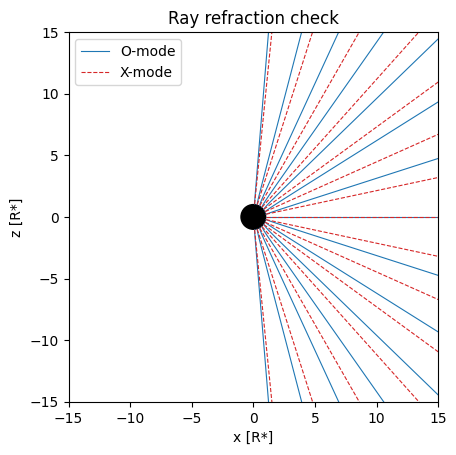

In [13]:
def trace_paths(x0, k0, isO, m, h_frac=0.01, max_steps=3000):
    """Integrate rays while storing the full trajectory of every ray, for visualization/debugging of refraction (no conversion or freezing applied).

    Args:
        x0        : (N,3) float array -- initial Cartesian positions in units of R_star.
        k0        : (N,3) float array -- initial wavevectors in units of omega/c.
        isO       : (N,) bool array   -- mode flags (True = O-mode, refracted; False = X-mode, straight).
        m         : Model             -- model parameters; m.r_out sets the stopping radius.
        h_frac    : float             -- step size as a fraction of local radius (default 0.01).
        max_steps : int               -- maximum number of stored steps (default 3000).

    Returns:
        (steps, N, 3) float array -- positions of every ray at every step.
    """
    x, k = x0.copy(), k0.copy()
    path = [x.copy()]
    for _ in range(max_steps):
        r = np.linalg.norm(x, axis=1)
        if (r > m.r_out).all(): break
        x, k = rk4_step(x, k, isO, h_frac*np.clip(r, None, m.r_out), m)
        path.append(x.copy())
    return np.array(path)          # (steps, N, 3)

Mdemo = Model(chi=0.0, wp2_surf=0.9)          # strong refraction demo, aligned dipole
th = np.linspace(0.1, np.pi-0.1, 15)
rhat = np.stack([np.sin(th), 0*th, np.cos(th)], axis=1)
x0 = 1.05 * rhat
for mode, style, lab in [(True, 'C0-', 'O-mode'), (False, 'C3--', 'X-mode')]:
    isO = np.full(len(x0), mode)
    n0  = np.where(isO, np.sqrt(np.clip(1 - wp2_w2(x0, Mdemo), 0, None)), 1.0)
    P   = trace_paths(x0, rhat*n0[:, None], isO, Mdemo)
    plt.plot(P[:, :, 0], P[:, :, 2], style, lw=0.8,
             label=[lab]+[None]*(len(x0)-1))
plt.gca().add_patch(plt.Circle((0, 0), 1, color='k'))
plt.xlim(-15, 15); plt.ylim(-15, 15); plt.gca().set_aspect(1)
plt.legend(); plt.xlabel('x [R*]'); plt.ylabel('z [R*]'); plt.title('Ray refraction check')
plt.show()

## Full simulation run

Launches a large ray ensemble from the polar cap and propagates it through the magnetosphere with the full conversion + freezing physics enabled. Adjust `N`, `cap_deg`, and `f_O` to change the emission geometry and initial mode mix.

In [ ]:
N = 2000000
# x0, k0, isO0, te = launch_radial(N, M, r_em=1.05, f_O=0.99)
x0, k0, isO0, te = launch_polar_cap(N, M, r_em=1.1, f_O=1.0, cap_deg=35.0)
res = propagate(x0, k0, isO0, M, t_emit=te)
print(f"escaped: {res['escaped'].sum()}, hit star: {res['hit'].sum()}, "
      f"mean conversions/ray: {res['nconv'].mean():.3f}, "
      f"final O fraction: {res['isO'][res['escaped']].mean():.3f}")

rays finished:   0%|          | 0/2000000 [00:00<?]

steps: 0/4000 [00:00, ?s/it]

## Sky maps

Bins escaped rays onto a (rotation phase, `cos θ`) grid and accumulates Stokes `I`, `Q`, `U`, and the X-mode fraction. The polarization angle reference is set by the *frozen* magnetic field direction at each ray's last coupled point (`Bfrz`), with O-mode PA parallel to the projected field and X-mode perpendicular — the standard convention in pulsar polarimetry.

In [ ]:
def make_maps(res, nph=360, nth=180):
    """Bin escaped rays onto a (phase/azimuth, cos-theta) sky grid and accumulate Stokes I, Q, U and X-mode fraction, with PA set by projected B at the freeze point (O parallel, X perpendicular).

    Args:
        res : dict -- output dictionary of propagate() (uses keys x, k, isO, Bfrz, escaped).
        nph : int  -- number of azimuthal (rotation phase) bins (default 120).
        nth : int  -- number of cos(theta) (line-of-sight colatitude) bins (default 60).

    Returns:
        dict with keys:
            I, Q, U : (nth, nph) binned Stokes maps,
            Xf      : (nth, nph) binned X-mode photon counts,
            phie    : (nph+1,) azimuth bin edges [rad],
            cthe    : (nth+1,) cos(theta) bin edges.
    """
    sel  = res['escaped']
    k    = res['k'][sel]; isO = res['isO'][sel]; B = res['Bfrz'][sel]
    khat = k / np.linalg.norm(k, axis=1, keepdims=True)
    cth  = khat[:, 2]
    phi  = np.mod(np.arctan2(khat[:, 1], khat[:, 0]), 2*np.pi)

    # sky basis perpendicular to khat (reference: celestial north = z)
    zax = np.array([0.0, 0.0, 1.0])
    e1  = np.cross(np.broadcast_to(zax, khat.shape), khat)
    bad = np.linalg.norm(e1, axis=1) < 1e-8
    e1[bad] = np.cross([1.0, 0, 0], khat[bad])
    e1 /= np.linalg.norm(e1, axis=1, keepdims=True)
    e2  = np.cross(khat, e1)

    psiB = np.arctan2(np.sum(B*e2, axis=1), np.sum(B*e1, axis=1))
    psi  = np.where(isO, psiB, psiB + np.pi/2)     # O || B_proj, X perp
    Q, U = np.cos(2*psi), np.sin(2*psi)

    bins = [np.linspace(0, 2*np.pi, nph+1), np.linspace(-1, 1, nth+1)]
    H  = lambda w: np.histogram2d(phi, cth, bins=bins, weights=w)[0].T
    I  = H(np.ones(len(phi)))
    return dict(I=I, Q=H(Q), U=H(U), Xf=H((~isO).astype(float)),
                phie=bins[0], cthe=bins[1])

def plot_maps(mp):
    """Plot the four all-sky maps (intensity, linear polarization fraction, polarization angle, X-mode fraction) from a make_maps() output.

    Args:
        mp : dict -- output dictionary of make_maps() (uses keys I, Q, U, Xf).

    Returns:
        (L, PA, Xf) : (nth, nph) arrays -- linear pol. fraction L/I, polarization angle [deg], and X-mode fraction, for further use.
    """
    I = mp['I'].copy(); I[I == 0] = np.nan
    L  = np.sqrt(mp['Q']**2 + mp['U']**2) / I
    PA = 0.5*np.rad2deg(np.arctan2(mp['U'], mp['Q']))
    Xf = mp['Xf'] / I
    ext = [0, 360, -1, 1]
    fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
    for a, dat, ttl, cm in zip(ax.flat,
            [I, L, PA, Xf],
            ['Intensity', 'Linear pol. fraction L/I', 'PA [deg]', 'X-mode fraction'],
            ['viridis', 'magma', 'twilight', 'coolwarm']):
        im = a.imshow(dat, origin='lower', extent=ext, aspect='auto', cmap=cm)
        a.set_title(ttl); fig.colorbar(im, ax=a)
    for a in ax[1]: a.set_xlabel('phase / azimuth [deg]')
    for a in ax[:, 0]: a.set_ylabel(r'$\cos\theta$ (line of sight)')
    plt.tight_layout(); plt.show()
    return L, PA, Xf

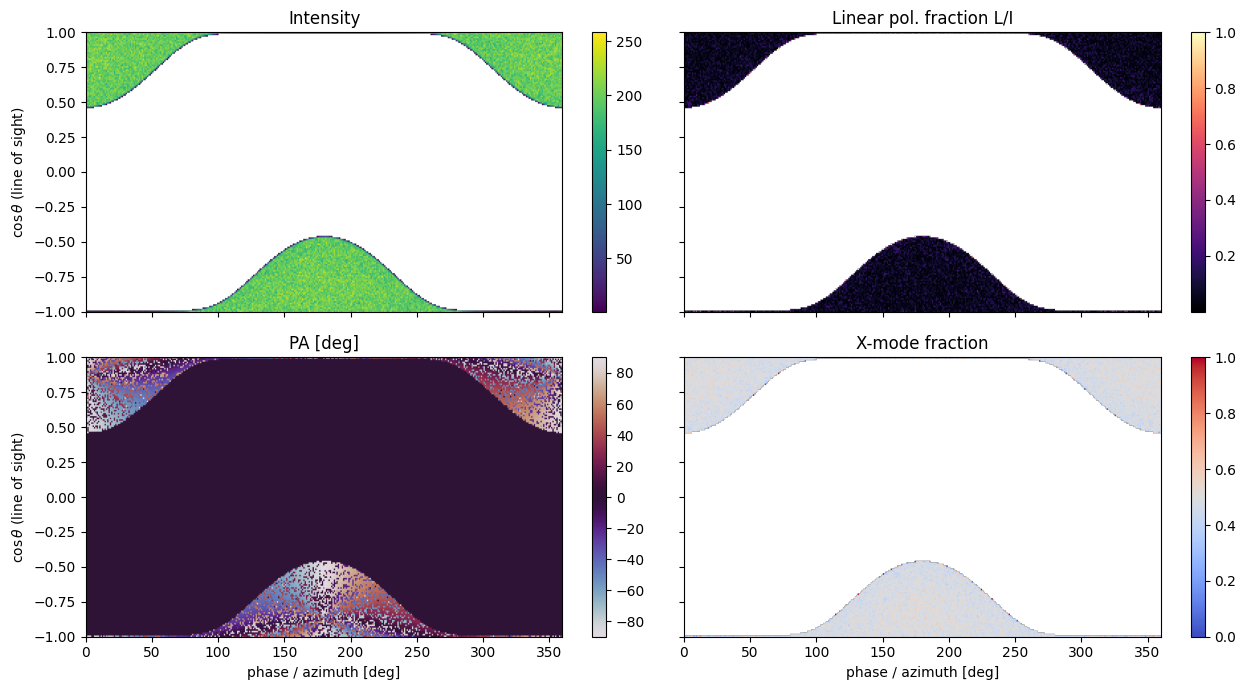

In [14]:
maps = make_maps(res)
L, PA, Xf = plot_maps(maps)

## Single-observer pulse profiles

Extracts a fixed-`ζ` (viewing angle) slice through the sky maps, producing the intensity, linear polarization fraction, PA-swing, and X-mode-fraction profiles a real observer would see as the star rotates — directly comparable to single-pulse or folded-profile polarimetric data.

In [15]:
def pulse_profile(mp, zeta_deg):
    """Extract and plot pulse profiles (I, L/I, PA, X-fraction vs. rotation phase) for an observer at a fixed viewing angle by slicing one row of the sky maps.

    Args:
        mp       : dict  -- output dictionary of make_maps() (uses keys I, Q, U, Xf, phie, cthe).
        zeta_deg : float -- observer's viewing angle zeta in degrees, measured from the rotation (z) axis.

    Returns:
        None -- displays a 4-panel matplotlib figure.
    """
    cz  = np.cos(np.deg2rad(zeta_deg))
    row = np.searchsorted(mp['cthe'], cz) - 1
    ph  = np.rad2deg(0.5*(mp['phie'][:-1] + mp['phie'][1:]))
    I   = mp['I'][row];  I_s = np.where(I > 0, I, np.nan)
    Lp  = np.sqrt(mp['Q'][row]**2 + mp['U'][row]**2)/I_s
    PAp = 0.5*np.rad2deg(np.arctan2(mp['U'][row], mp['Q'][row]))
    Xfp = mp['Xf'][row]/I_s

    fig, ax = plt.subplots(4, 1, figsize=(8, 9), sharex=True)
    ax[0].plot(ph, I);   ax[0].set_ylabel('I')
    ax[1].plot(ph, Lp);  ax[1].set_ylabel('L/I'); ax[1].set_ylim(0, 1.05)
    ax[2].plot(ph, PAp, '.'); ax[2].set_ylabel('PA [deg]')
    ax[3].plot(ph, Xfp); ax[3].set_ylabel('X fraction'); ax[3].set_ylim(0, 1.05)
    ax[3].set_xlabel('rotation phase [deg]')
    fig.suptitle(f'Observer at zeta = {zeta_deg} deg (chi = {np.rad2deg(M.chi):.0f} deg)')
    plt.tight_layout(); plt.show()

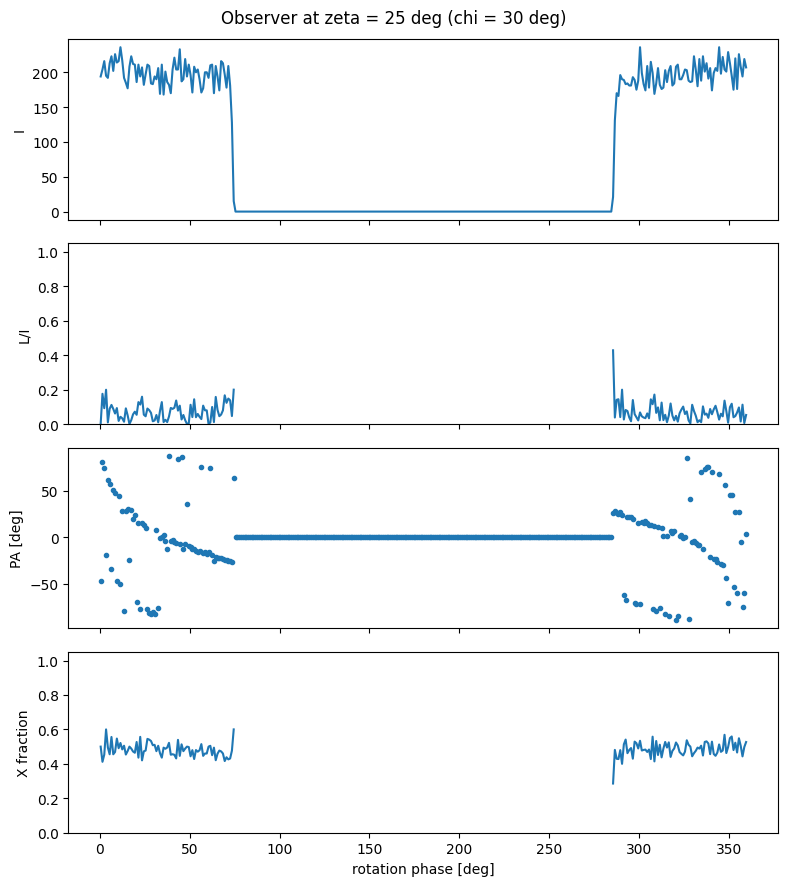

In [16]:
pulse_profile(maps, zeta_deg=25)

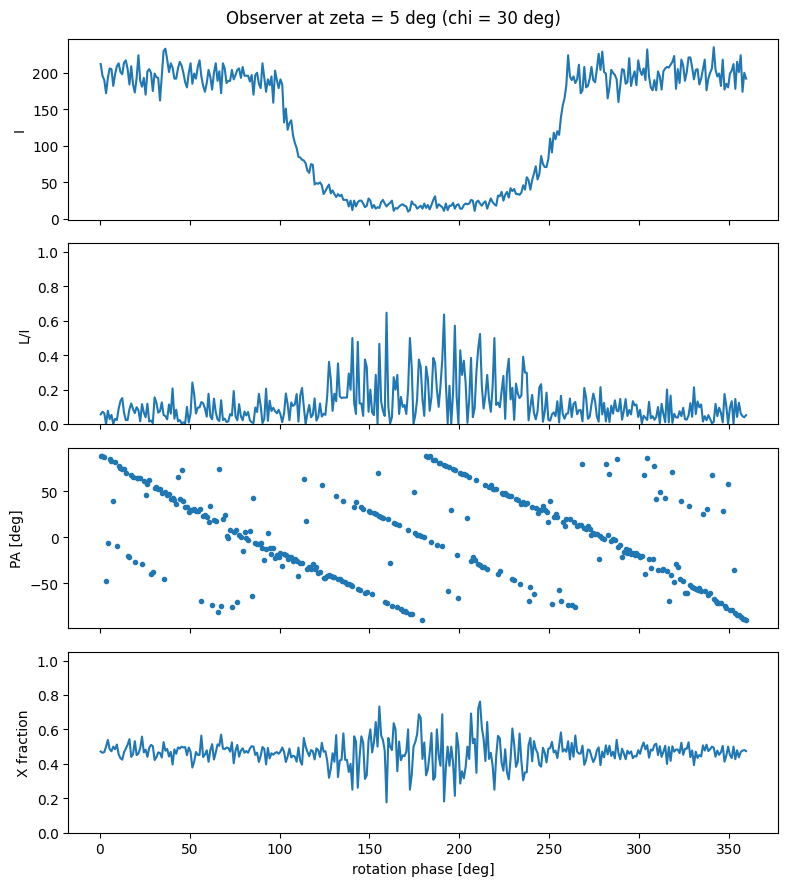

In [17]:
pulse_profile(maps, zeta_deg=5)